# Workshop 2 – Automatización de un pipeline ETL con Apache Airflow
**Spotify (CSV) + Grammy Awards (base de datos SQL)**

## Introducción
Este notebook construye un pipeline ETL orquestado con **Apache Airflow** que:
1. **Extrae** Spotify desde un CSV y Grammys desde una base de datos SQL (SQLite).
2. **Valida** la calidad del dataset de Spotify con **Pandera** (tipos, nulos y rangos) e indica si pasa o falla.
3. **Transforma** ambos datasets y los **combina** (merge).
4. **Carga** el resultado en la base de datos y lo **exporta** a CSV.
5. Genera un **reporte estático** leyendo *únicamente desde la base de datos*.

## Flujo del pipeline (DAG `spotify_grammys_etl`)
```
read_csv -> validate_csv -> transform_csv --\
                                             +--> merge -> load -> store
read_db  -> transform_db  -----------------/
```
| Tarea | Qué hace |
|---|---|
| `read_csv` | Lee el CSV de Spotify |
| `validate_csv` | Valida con Pandera; genera `validation_report.json`; falla el DAG si hay errores graves |
| `transform_csv` | Elimina columna sobrante y duplicados, crea `duration_min` y `primary_artist` |
| `read_db` | Lee la tabla `grammys_raw` desde la BD SQL |
| `transform_db` | Agrega Grammys por artista (nominaciones, primer y último año); si `artist` viene vacío lo recupera desde `workers` |
| `merge` | LEFT JOIN por artista normalizado; cada canción hereda los datos de su artista más nominado (1 fila por canción) |
| `load` | Carga la tabla `spotify_grammys_merged` en la BD |
| `store` | Exporta la tabla final a `data/transformed_dataset.csv` |

## Cómo ejecutar este notebook
1. Menú **Entorno de ejecución → Ejecutar todo** (las celdas están en orden; no saltes ninguna).
2. Si la descarga de Kaggle falla, la sección 3 te pedirá subir los dos CSV manualmente.
3. Al final (sección 12) se descargan los entregables: CSV transformado y reporte de validación.

## Índice
1. Instalación · 2. Estructura del proyecto · 3. Datos (descarga y exploración) · 4. Módulos `src/` ·
5. Carga de Grammys a la BD · 6. DAG de Airflow y diagrama · 7. Ejecución del pipeline ·
8. Calidad de datos · 9. Verificación de la BD · 10. Reporte estático · 11. Conclusiones · 12. Exportar entregables

## 1. Instalación de dependencias

In [1]:
!pip install -q apache-airflow pandera sqlalchemy pandas matplotlib seaborn kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.5/607.5 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.0/535.0 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71

## 2. Estructura del proyecto
Se crean los paquetes `src` (lógica ETL) y `dags` (orquestación), y la carpeta `data`.

In [2]:
import os
for d in ["src", "dags", "data"]:
    os.makedirs(d, exist_ok=True)
print("Carpetas creadas:", [d for d in ["src", "dags", "data"]])

Carpetas creadas: ['src', 'dags', 'data']


## 3. Descarga de los datasets (Kaggle)
- **Grammy Awards** → se cargará a la base de datos (fuente SQL).
- **Spotify Tracks** → se leerá como CSV.

In [3]:
import os, glob, shutil

def descargar(slug, destino, pista):
    import kagglehub
    ruta = kagglehub.dataset_download(slug)
    csvs = sorted(glob.glob(os.path.join(ruta, "**", "*.csv"), recursive=True))
    elegido = next((c for c in csvs if pista in os.path.basename(c).lower()), csvs[0])
    shutil.copy(elegido, destino)
    print(f"OK  {slug} -> {destino}")

fuentes = {
    "data/grammys_raw.csv":    ("unanimad/grammy-awards", "grammy"),
    "data/spotify_tracks.csv": ("maharshipandya/-spotify-tracks-dataset", "dataset"),
}
faltan = []
for destino, (slug, pista) in fuentes.items():
    try:
        descargar(slug, destino, pista)
    except Exception as e:
        print(f"ERR {slug}: {repr(e)[:150]}")
        faltan.append(destino)

# Respaldo: subida manual si Kaggle no respondió
if faltan:
    from google.colab import files
    print("\nSube manualmente los CSV que faltan:", faltan)
    for nombre, contenido in files.upload().items():
        destino = "data/grammys_raw.csv" if "grammy" in nombre.lower() else "data/spotify_tracks.csv"
        open(destino, "wb").write(contenido)
        print("Guardado", nombre, "->", destino)

print("\nArchivos en data/:", os.listdir("data"))

100%|██████████| 261k/261k [00:00<00:00, 51.1MB/s]

Extracting files...
OK  unanimad/grammy-awards -> data/grammys_raw.csv


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
OK  maharshipandya/-spotify-tracks-dataset -> data/spotify_tracks.csv

Archivos en data/: ['spotify_tracks.csv', 'grammys_raw.csv']


### 3.1 Exploración inicial y verificación de columnas
Confirma que ambos datasets traen las columnas que usa el pipeline antes de ejecutarlo.

In [4]:
import pandas as pd
sp = pd.read_csv("data/spotify_tracks.csv")
gr = pd.read_csv("data/grammys_raw.csv")

esperadas_sp = {"track_id", "artists", "album_name", "track_name", "popularity", "duration_ms", "explicit",
                "danceability", "energy", "loudness", "speechiness", "acousticness", "valence", "tempo", "track_genre"}
esperadas_gr = {"year", "category", "artist", "winner"}
falt_sp, falt_gr = esperadas_sp - set(sp.columns), esperadas_gr - set(gr.columns)
assert not falt_sp and not falt_gr, f"Columnas faltantes -> Spotify: {falt_sp} | Grammys: {falt_gr}"

print(f"Spotify: {sp.shape[0]:,} filas x {sp.shape[1]} columnas | Grammys: {gr.shape[0]:,} filas x {gr.shape[1]} columnas")
print("\nValores nulos en Spotify:\n", sp.isna().sum()[sp.isna().sum() > 0].to_string() or "ninguno")
print("\nGrammys con artista nulo:", gr["artist"].isna().sum(), "de", len(gr))
display(sp.head(3)); display(gr.head(3))

Spotify: 114,000 filas x 21 columnas | Grammys: 4,810 filas x 10 columnas

Valores nulos en Spotify:
 artists       1
album_name    1
track_name    1

Grammys con artista nulo: 1840 de 4810


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True


## 4. Módulos del proyecto (`src/`)
Cada celda escribe un archivo `.py` que luego usa el DAG.

### 4.1 `config.py` – rutas y parámetros

In [5]:
%%writefile src/config.py
"""Rutas y parámetros globales del pipeline."""
import os
from pathlib import Path

PROJECT_DIR = Path(os.getenv("PROJECT_DIR", os.getcwd())).resolve()
DATA = PROJECT_DIR / "data"
STAGING = DATA / "staging"      # archivos intermedios entre tareas
REPORTS = DATA / "reports"      # reporte de calidad de datos

SPOTIFY_RAW = DATA / "spotify_tracks.csv"
GRAMMYS_RAW = DATA / "grammys_raw.csv"

DB_URL = f"sqlite:///{DATA / 'etl_workshop.db'}"
GRAMMYS_TABLE = "grammys_raw"                 # fuente (base de datos)
FINAL_TABLE = "spotify_grammys_merged"        # destino
FINAL_CSV = DATA / "transformed_dataset.csv"

MAX_INVALID_PCT = 5.0   # si más de 5 % de filas incumplen reglas => la validación FALLA


def ensure_dirs():
    for d in (DATA, STAGING, REPORTS):
        d.mkdir(parents=True, exist_ok=True)


Writing src/config.py


In [6]:
%%writefile src/__init__.py


Writing src/__init__.py


### 4.2 `database.py` – conexión y carga inicial de Grammys a la BD SQL

In [7]:
%%writefile src/database.py
import pandas as pd
from sqlalchemy import create_engine

from src import config as cfg


def get_engine():
    return create_engine(cfg.DB_URL)


def init_db_grammys(csv_path=None):
    """Carga inicial del CSV de Grammys a la BD SQL (esta será la 'base de datos fuente')."""
    cfg.ensure_dirs()
    df = pd.read_csv(csv_path or cfg.GRAMMYS_RAW)
    df.to_sql(cfg.GRAMMYS_TABLE, con=get_engine(), if_exists="replace", index=False)
    print(f"Tabla '{cfg.GRAMMYS_TABLE}' cargada en la BD SQL: {df.shape[0]} filas, {df.shape[1]} columnas.")


Writing src/database.py


### 4.3 `quality.py` – calidad de datos con Pandera
**Reglas:** tipos de dato, `track_id`/`artists`/`track_name`/`track_genre` no nulos, `popularity` 0–100, `duration_ms` > 0,
variables de audio entre 0 y 1, `loudness` entre -60 y 5 dB, `tempo` ≥ 0.
**Resultado:** `PASSED`, `PASSED_WITH_WARNINGS` (≤ 5 % de filas inválidas, que se apartan en `rejected_rows.csv`) o `FAILED`
(error estructural o > 5 % de filas inválidas → el DAG se detiene).

In [8]:
%%writefile src/quality.py
"""Calidad de datos con Pandera para el dataset de Spotify."""
import pandas as pd

try:
    import pandera.pandas as pa
except ImportError:          # versiones antiguas de pandera
    import pandera as pa

from src import config as cfg


class DataQualityError(Exception):
    """La validación de calidad de datos falló."""


spotify_schema = pa.DataFrameSchema(
    {
        "track_id": pa.Column(str, nullable=False),
        "artists": pa.Column(str, nullable=False),
        "track_name": pa.Column(str, nullable=False),
        "album_name": pa.Column(str, nullable=True),
        "popularity": pa.Column(int, pa.Check.in_range(0, 100)),
        "duration_ms": pa.Column(int, pa.Check.gt(0)),
        "explicit": pa.Column(bool),
        "danceability": pa.Column(float, pa.Check.in_range(0, 1)),
        "energy": pa.Column(float, pa.Check.in_range(0, 1)),
        "loudness": pa.Column(float, pa.Check.in_range(-60, 5)),
        "speechiness": pa.Column(float, pa.Check.in_range(0, 1)),
        "acousticness": pa.Column(float, pa.Check.in_range(0, 1)),
        "valence": pa.Column(float, pa.Check.in_range(0, 1)),
        "tempo": pa.Column(float, pa.Check.ge(0)),
        "track_genre": pa.Column(str, nullable=False),
    },
    coerce=True,
    strict=False,
)


def _summarize(failure_cases: pd.DataFrame):
    g = (failure_cases.groupby(["column", "check"], dropna=False)
         .size().reset_index(name="filas_afectadas")
         .sort_values("filas_afectadas", ascending=False))
    return g.astype(str).to_dict("records")


def validate_spotify_data(df: pd.DataFrame):
    """Devuelve (df_limpio, df_rechazado, reporte).
    Estados: PASSED | PASSED_WITH_WARNINGS | FAILED."""
    report = {"dataset": "spotify", "rows_total": int(len(df))}
    try:
        clean = spotify_schema.validate(df, lazy=True)
        report.update(status="PASSED", rows_invalid=0, invalid_pct=0.0, errors=[])
        return clean, df.iloc[0:0], report
    except pa.errors.SchemaErrors as exc:
        fc = exc.failure_cases
        report["errors"] = _summarize(fc)
        # Sin índice de fila => error estructural (columna faltante / tipo imposible de convertir)
        if fc["index"].isna().any():
            report.update(status="FAILED", rows_invalid=None, invalid_pct=None,
                          reason="Error estructural: columnas faltantes o tipos inválidos")
            return None, None, report
        bad = fc["index"].dropna().unique()
        rejected = df.loc[df.index.isin(bad)]
        pct = round(len(rejected) / len(df) * 100, 4)
        report.update(rows_invalid=int(len(rejected)), invalid_pct=pct)
        if pct > cfg.MAX_INVALID_PCT:
            report.update(status="FAILED",
                          reason=f"{pct}% de filas inválidas supera el umbral de {cfg.MAX_INVALID_PCT}%")
            return None, rejected, report
        clean = spotify_schema.validate(df.drop(index=rejected.index))
        report.update(status="PASSED_WITH_WARNINGS",
                      reason="Filas inválidas separadas en data/reports/rejected_rows.csv")
        return clean, rejected, report


Writing src/quality.py


### 4.4 `transform.py` – transformaciones y merge
- **Spotify:** sin columna `Unnamed`, sin duplicados por `track_id`, `duration_min` y `primary_artist`.
- **Grammys:** si `artist` está vacío (≈38 % de las filas) se recupera desde `workers` (texto entre paréntesis, p. ej. `songwriters (Lady Gaga)`).
  "A Featuring B" / "A & B" se separan en un artista por nombre. Se agrega **por artista** (nominaciones, primer y último año).
  Se excluyen nombres genéricos (`Various Artists`, `Conductor`, ...) que producirían cruces falsos.
- **Columna `winner`:** en este dataset vale `True` en las 4.810 filas, así que no distingue ganadores de nominados y **no se usa**; se trabaja con *nominaciones*.
- **Merge:** `LEFT JOIN` por nombre normalizado (minúsculas, sin tildes). Cada artista de la canción (`A;B`) se cruza por separado y la canción
  hereda los datos del artista más nominado → columnas `grammy_artist`, `grammy_nominations`, `grammy_artists` y `has_grammy_nomination`.

In [9]:
%%writefile src/transform.py
import re
import unicodedata

import pandas as pd

_SPLIT = re.compile(r"\s+(?:featuring|feat\.?|with|and|&)\s+|,|;|/", flags=re.I)

# Nombres genéricos que NO identifican a un artista (evitan cruces falsos entre datasets)
GENERIC_KEYS = {"various artists", "various", "conductor", "soloist", "soloists", "orchestra", "chorus",
                "original broadway cast", "original cast", "cast", "soundtrack", "original soundtrack",
                "composer", "producer", "unknown", "anonymous"}


def normalize_name(value) -> str:
    """'Beyoncé ' -> 'beyonce'. Llave común para cruzar Spotify con Grammys."""
    if not isinstance(value, str):
        return ""
    value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode()
    value = re.sub(r"[^a-z0-9 ]", " ", value.lower())
    return re.sub(r"\s+", " ", value).strip()


def grammy_artist_keys(artist, workers) -> set:
    """Llaves de artista de una fila de Grammys.
    - Si `artist` viene vacío, se recupera de `workers` (texto entre paréntesis: '..., songwriters (Lady Gaga)').
    - 'A Featuring B' / 'A & B' genera la llave completa y una llave por cada artista."""
    if isinstance(artist, str) and artist.strip():
        sources = [artist]
    elif isinstance(workers, str):
        sources = re.findall(r"\(([^()]+)\)", workers)
    else:
        sources = []
    keys = set()
    for src in sources:
        keys.add(normalize_name(src))
        keys.update(normalize_name(p) for p in _SPLIT.split(src))
    return {k for k in keys if len(k) >= 2 and k not in GENERIC_KEYS and not k.isdigit()}


def transform_spotify(df: pd.DataFrame) -> pd.DataFrame:
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")].copy()      # quita índice sobrante
    df = df.drop_duplicates(subset="track_id")                         # un track puede repetirse por género
    df["duration_min"] = (df["duration_ms"] / 60000).round(2)
    df["primary_artist"] = df["artists"].astype(str).str.split(";").str[0].str.strip()
    return df


def transform_grammys(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega los Grammys por artista: nominaciones y rango de años.
    NOTA: en este dataset la columna `winner` es True en todas las filas, por lo que NO se usa
    (cada fila es una nominación/entrada de categoría)."""
    df = df.copy()
    df["artist_clean"] = [grammy_artist_keys(a, w) for a, w in zip(df.get("artist"), df.get("workers"))]
    df = df[df["artist_clean"].map(len) > 0].explode("artist_clean")
    return (df.groupby("artist_clean", as_index=False)
              .agg(grammy_nominations=("category", "size"),
                   grammy_first_year=("year", "min"),
                   grammy_last_year=("year", "max")))


def merge_datasets(df_spotify: pd.DataFrame, df_grammys: pd.DataFrame) -> pd.DataFrame:
    """LEFT JOIN: se conservan TODAS las canciones, 1 fila por track.
    Cada artista de la canción ('A;B') se cruza por separado; la canción hereda los datos del
    artista MÁS nominado entre sus artistas (columna `grammy_artist`)."""
    ex = df_spotify[["track_id", "artists"]].copy()
    ex["artist_raw"] = ex["artists"].astype(str).str.split(";")
    ex = ex.explode("artist_raw")
    ex["artist_clean"] = ex["artist_raw"].map(normalize_name)

    joined = ex.merge(df_grammys, on="artist_clean", how="left")
    n_matched = (joined.groupby("track_id")["grammy_nominations"].apply(lambda s: int(s.notna().sum()))
                 .rename("grammy_artists").reset_index())
    best = (joined.sort_values("grammy_nominations", ascending=False, na_position="last")
                  .drop_duplicates("track_id")
                  [["track_id", "artist_raw", "grammy_nominations", "grammy_first_year", "grammy_last_year"]]
                  .rename(columns={"artist_raw": "grammy_artist"}))
    best.loc[best["grammy_nominations"].isna(), "grammy_artist"] = None

    out = df_spotify.merge(best, on="track_id", how="left").merge(n_matched, on="track_id", how="left")
    out["grammy_nominations"] = out["grammy_nominations"].fillna(0).astype(int)
    out["has_grammy_nomination"] = out["grammy_nominations"] > 0
    return out


Writing src/transform.py


### 4.5 `load.py` – carga a la BD y exportación a CSV

In [10]:
%%writefile src/load.py
from src import config as cfg
from src.database import get_engine


def save_to_db(df, table_name=None):
    table_name = table_name or cfg.FINAL_TABLE
    df.to_sql(table_name, con=get_engine(), if_exists="replace", index=False, chunksize=5000)
    print(f"{len(df)} filas cargadas en la BD (tabla: {table_name}).")


def export_to_csv(df, output_path=None):
    output_path = output_path or cfg.FINAL_CSV
    df.to_csv(output_path, index=False)
    print(f"CSV exportado en: {output_path}")


Writing src/load.py


### 4.6 `tasks.py` – lógica de cada tarea del DAG

In [11]:
%%writefile src/tasks.py
"""Lógica de cada tarea del DAG (Python/pandas puro, sin dependencia de Airflow)."""
import json

import pandas as pd

from src import config as cfg
from src.database import get_engine
from src.load import export_to_csv, save_to_db
from src.quality import DataQualityError, validate_spotify_data
from src.transform import merge_datasets, transform_grammys, transform_spotify


def read_csv():
    cfg.ensure_dirs()
    df = pd.read_csv(cfg.SPOTIFY_RAW)
    df.to_csv(cfg.STAGING / "spotify_raw.csv", index=False)
    print(f"[read_csv] Spotify leído desde CSV: {df.shape}")


def read_db():
    cfg.ensure_dirs()
    df = pd.read_sql(f"SELECT * FROM {cfg.GRAMMYS_TABLE}", get_engine())
    if df.empty:
        raise DataQualityError("La tabla de Grammys está vacía")
    df.to_csv(cfg.STAGING / "grammys_raw.csv", index=False)
    print(f"[read_db] Grammys leído desde la BD SQL: {df.shape}")


def validate_csv():
    df = pd.read_csv(cfg.STAGING / "spotify_raw.csv")
    clean, rejected, report = validate_spotify_data(df)
    (cfg.REPORTS / "validation_report.json").write_text(json.dumps(report, indent=2, ensure_ascii=False))
    print(f"[validate_csv] Estado: {report['status']} | filas inválidas: {report['rows_invalid']} "
          f"({report['invalid_pct']}%)")
    if rejected is not None and len(rejected):
        rejected.to_csv(cfg.REPORTS / "rejected_rows.csv", index=False)
    if report["status"] == "FAILED":
        raise DataQualityError(report.get("reason", "Validación fallida"))
    clean.to_csv(cfg.STAGING / "spotify_clean.csv", index=False)


def transform_csv():
    df = transform_spotify(pd.read_csv(cfg.STAGING / "spotify_clean.csv"))
    df.to_csv(cfg.STAGING / "spotify_transformed.csv", index=False)
    print(f"[transform_csv] Spotify transformado: {df.shape}")


def transform_db():
    df = transform_grammys(pd.read_csv(cfg.STAGING / "grammys_raw.csv"))
    df.to_csv(cfg.STAGING / "grammys_transformed.csv", index=False)
    print(f"[transform_db] Grammys agregado por artista: {df.shape}")


def merge():
    sp = pd.read_csv(cfg.STAGING / "spotify_transformed.csv")
    gr = pd.read_csv(cfg.STAGING / "grammys_transformed.csv")
    out = merge_datasets(sp, gr)
    out.to_csv(cfg.STAGING / "merged.csv", index=False)
    print(f"[merge] Dataset final: {out.shape} | canciones con nominación: {int(out['has_grammy_nomination'].sum())}")


def load():
    save_to_db(pd.read_csv(cfg.STAGING / "merged.csv"))


def store():
    df = pd.read_sql(f"SELECT * FROM {cfg.FINAL_TABLE}", get_engine())   # se exporta lo que quedó en la BD
    export_to_csv(df)


Writing src/tasks.py


## 5. Carga previa de Grammys a la base de datos SQL
Crea la tabla `grammys_raw`, que será la fuente de la tarea `read_db`.

In [12]:
from src.database import init_db_grammys
init_db_grammys()

Tabla 'grammys_raw' cargada en la BD SQL: 4810 filas, 10 columnas.


## 6. DAG de Airflow
Define las 8 tareas (`PythonOperator`) y sus dependencias.

In [13]:
%%writefile dags/spotify_grammys_dag.py
"""
DAG: spotify_grammys_etl

read_csv -> validate_csv -> transform_csv --\
                                             +--> merge -> load -> store
read_db  -> transform_db  -----------------/
"""
from datetime import datetime

try:                                              # Airflow 3
    from airflow.sdk import DAG
    from airflow.providers.standard.operators.python import PythonOperator
except ImportError:                               # Airflow 2
    from airflow import DAG
    from airflow.operators.python import PythonOperator

from src import tasks

with DAG(
    dag_id="spotify_grammys_etl",
    start_date=datetime(2024, 1, 1),
    schedule=None,
    catchup=False,
    tags=["workshop", "etl"],
) as dag:
    t_read_csv = PythonOperator(task_id="read_csv", python_callable=tasks.read_csv)
    t_validate = PythonOperator(task_id="validate_csv", python_callable=tasks.validate_csv)
    t_transform_csv = PythonOperator(task_id="transform_csv", python_callable=tasks.transform_csv)
    t_read_db = PythonOperator(task_id="read_db", python_callable=tasks.read_db)
    t_transform_db = PythonOperator(task_id="transform_db", python_callable=tasks.transform_db)
    t_merge = PythonOperator(task_id="merge", python_callable=tasks.merge)
    t_load = PythonOperator(task_id="load", python_callable=tasks.load)
    t_store = PythonOperator(task_id="store", python_callable=tasks.store)

    t_read_csv >> t_validate >> t_transform_csv >> t_merge
    t_read_db >> t_transform_db >> t_merge
    t_merge >> t_load >> t_store

# Orden de respaldo (solo se usa si dag.test() no pudiera ejecutarse en el entorno)
FALLBACK_ORDER = ["read_csv", "validate_csv", "transform_csv", "read_db",
                  "transform_db", "merge", "load", "store"]


Writing dags/spotify_grammys_dag.py


### 6.1 Diagrama del DAG

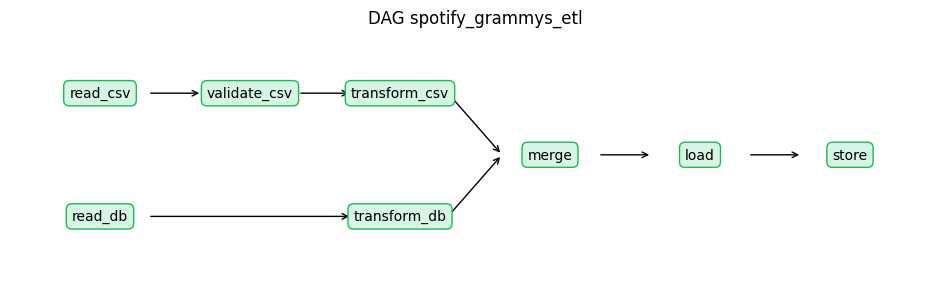

read_csv        -> ['validate_csv']
validate_csv    -> ['transform_csv']
transform_csv   -> ['merge']
read_db         -> ['transform_db']
transform_db    -> ['merge']
merge           -> ['load']
load            -> ['store']
store           -> []


In [14]:
import importlib, os, sys
# Configuración de Airflow (debe hacerse ANTES de importar airflow)
os.environ["AIRFLOW__CORE__LOAD_EXAMPLES"] = "False"
os.environ["AIRFLOW__CORE__DAGS_FOLDER"] = os.path.abspath("dags")
os.environ["PROJECT_DIR"] = os.getcwd()
sys.path.insert(0, os.getcwd())
!airflow db migrate > /dev/null 2>&1
!airflow dags reserialize > /dev/null 2>&1
import dags.spotify_grammys_dag as m
importlib.reload(m)
dag = m.dag

import matplotlib.pyplot as plt
pos = {"read_csv": (0, 1), "validate_csv": (1, 1), "transform_csv": (2, 1), "read_db": (0, 0),
       "transform_db": (2, 0), "merge": (3, .5), "load": (4, .5), "store": (5, .5)}
fig, ax = plt.subplots(figsize=(12, 3.2))
for t in dag.tasks:
    for d in t.downstream_task_ids:
        (x1, y1), (x2, y2) = pos[t.task_id], pos[d]
        ax.annotate("", xy=(x2 - .32, y2), xytext=(x1 + .32, y1), arrowprops=dict(arrowstyle="->"))
for name, (x, y) in pos.items():
    ax.text(x, y, name, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=.4", fc="#d7f5e3", ec="#1DB954"))
ax.set_xlim(-.6, 5.6); ax.set_ylim(-.5, 1.5); ax.axis("off")
ax.set_title("DAG spotify_grammys_etl")
plt.show()
for t in dag.tasks:
    print(f"{t.task_id:15s} -> {sorted(t.downstream_task_ids)}")

## 7. Ejecución del pipeline con Airflow
`dag.test()` ejecuta el DAG completo respetando el orden y las dependencias (equivale a un *DAG run* con todas las tareas en verde).

In [15]:
try:
    run = dag.test()
    print("\nDAG ejecutado con Airflow (dag.test()).")
except Exception as e:                                   # respaldo si el entorno no permite dag.test()
    print("dag.test() no disponible en este entorno:", repr(e)[:200])
    print("Ejecutando las tareas en el orden del DAG...\n")
    for task_id in m.FALLBACK_ORDER:
        dag.get_task(task_id).python_callable()

2026-10-08T02:56:30.761189Z [info     ] DAG bundles loaded: dags-folder [airflow.dag_processing.bundles.manager.DagBundlesManager] loc=manager.py:304
2026-10-08T02:56:30.774345Z [info     ] Filling up the DagBag from /content/dags [airflow.dag_processing.dagbag.BundleDagBag] loc=dagbag.py:460
2026-10-08T02:56:30.788578Z [info     ] Bulk-writing dags to db        [airflow.serialization.definitions.dag] count=1 loc=dag.py:218
2026-10-08T02:56:30.803641Z [info     ] Creating ORM DAG for spotify_grammys_etl [airflow.dag_processing.collection] loc=collection.py:102
2026-10-08T02:56:30.806026Z [info     ] get next_dagrun_info_v2        [airflow.serialization.definitions.dag] last_automated_run_info=None loc=dag.py:453 next_info=None
2026-10-08T02:56:30.808589Z [info     ] setting next dagrun info       [airflow.models.dag] loc=dag.py:848 next_dagrun=None next_dagrun_create_after=None next_dagrun_data_interval_end=None next_dagrun_data_interval_start=None next_dagrun_partition_date=None next_

## 8. Evidencia de calidad de datos

In [16]:
import json
rep = json.load(open("data/reports/validation_report.json"))
print("ESTADO DE LA VALIDACIÓN:", rep["status"])
print("Filas totales   :", rep["rows_total"])
print("Filas inválidas :", rep["rows_invalid"], f"({rep['invalid_pct']} %)")
print("Reglas incumplidas:")
for e in rep["errors"]:
    print("  -", e)

ESTADO DE LA VALIDACIÓN: PASSED_WITH_WARNINGS
Filas totales   : 114000
Filas inválidas : 1 (0.0009 %)
Reglas incumplidas:
  - {'column': 'artists', 'check': 'not_nullable', 'filas_afectadas': '1'}
  - {'column': 'duration_ms', 'check': 'greater_than(0)', 'filas_afectadas': '1'}
  - {'column': 'track_name', 'check': 'not_nullable', 'filas_afectadas': '1'}


## 9. Verificación de la base de datos

In [17]:
import pandas as pd
from src.database import get_engine
eng = get_engine()
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", eng))
print(pd.read_sql("SELECT COUNT(*) AS filas_tabla_final FROM spotify_grammys_merged", eng))
pd.read_sql("SELECT * FROM spotify_grammys_merged LIMIT 5", eng)

                     name
0             grammys_raw
1  spotify_grammys_merged
   filas_tabla_final
0              89740


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,time_signature,track_genre,duration_min,primary_artist,grammy_artist,grammy_nominations,grammy_first_year,grammy_last_year,grammy_artists,has_grammy_nomination
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,4,acoustic,3.84,Gen Hoshino,None,0,None,None,0,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,4,acoustic,2.49,Ben Woodward,None,0,None,None,0,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,4,acoustic,3.51,Ingrid Michaelson,None,0,None,None,0,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,3,acoustic,3.37,Kina Grannis,None,0,None,None,0,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,4,acoustic,3.31,Chord Overstreet,None,0,None,None,0,0


## 10. Reporte estático (leído desde la base de datos)
Todas las consultas se hacen sobre la tabla `spotify_grammys_merged`, no sobre el CSV.

In [18]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import config as cfg
sns.set_theme(style="whitegrid")
conn = sqlite3.connect(cfg.DATA / "etl_workshop.db")
q = lambda sql: pd.read_sql_query(sql, conn)

q("""SELECT COUNT(*) AS canciones,
            COUNT(DISTINCT primary_artist) AS artistas,
            ROUND(AVG(popularity), 1) AS popularidad_media,
            SUM(has_grammy_nomination) AS canciones_de_artistas_nominados,
            COUNT(DISTINCT CASE WHEN has_grammy_nomination = 1 THEN primary_artist END) AS artistas_nominados
     FROM spotify_grammys_merged""")

,canciones,artistas,popularidad_media,canciones_de_artistas_nominados,artistas_nominados
0,89740,17648,33.2,9680,1134


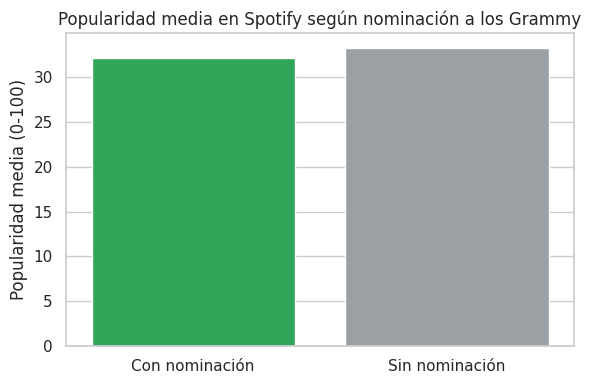

In [19]:
# Gráfico 1: popularidad media, artistas nominados vs no nominados
d = q("""SELECT CASE WHEN has_grammy_nomination = 1 THEN 'Con nominación' ELSE 'Sin nominación' END AS grupo,
                ROUND(AVG(popularity), 2) AS popularidad
         FROM spotify_grammys_merged GROUP BY 1""")
plt.figure(figsize=(6, 4))
sns.barplot(data=d, x="grupo", y="popularidad", hue="grupo", palette=["#1DB954", "#9aa0a6"], legend=False)
plt.title("Popularidad media en Spotify según nominación a los Grammy")
plt.xlabel(""); plt.ylabel("Popularidad media (0-100)"); plt.tight_layout(); plt.show()

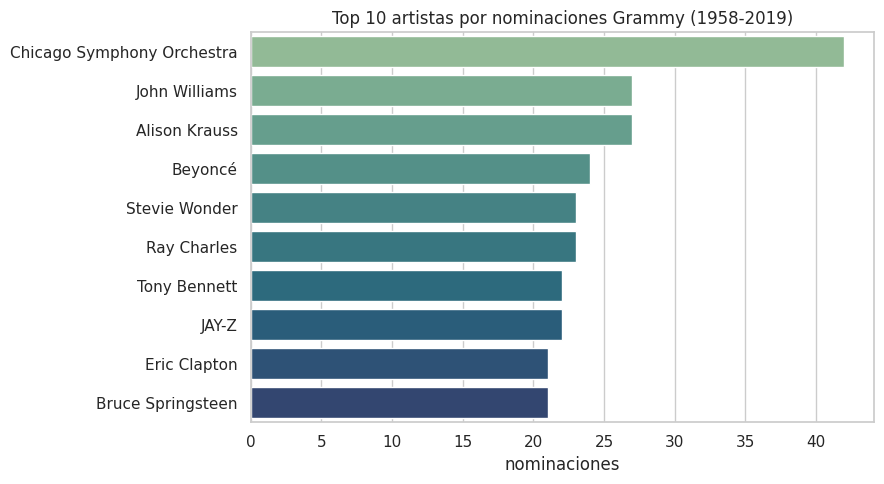

In [20]:
# Gráfico 2: top 10 artistas con más nominaciones Grammy (presentes en Spotify)
d = q("""SELECT grammy_artist AS artista, MAX(grammy_nominations) AS nominaciones
         FROM spotify_grammys_merged WHERE has_grammy_nomination = 1
         GROUP BY 1 ORDER BY nominaciones DESC LIMIT 10""")
plt.figure(figsize=(9, 5))
sns.barplot(data=d, x="nominaciones", y="artista", hue="artista", palette="crest", legend=False)
plt.title("Top 10 artistas por nominaciones Grammy (1958-2019)"); plt.ylabel(""); plt.tight_layout(); plt.show()

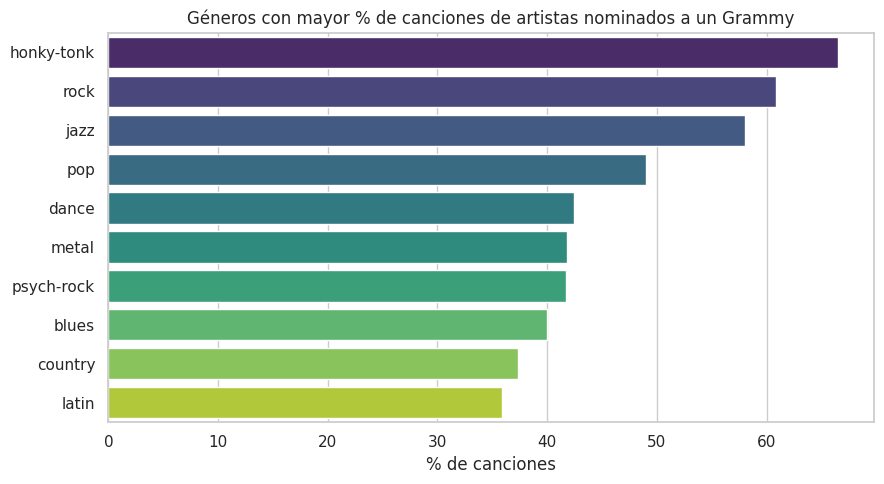

In [21]:
# Gráfico 3: géneros con mayor porcentaje de canciones de artistas nominados (mín. 200 canciones)
d = q("""SELECT track_genre AS genero, COUNT(*) AS n,
                ROUND(100.0 * SUM(has_grammy_nomination) / COUNT(*), 2) AS pct_nominados
         FROM spotify_grammys_merged GROUP BY 1 HAVING COUNT(*) >= 200
         ORDER BY pct_nominados DESC LIMIT 10""")
plt.figure(figsize=(9, 5))
sns.barplot(data=d, x="pct_nominados", y="genero", hue="genero", palette="viridis", legend=False)
plt.title("Géneros con mayor % de canciones de artistas nominados a un Grammy")
plt.xlabel("% de canciones"); plt.ylabel(""); plt.tight_layout(); plt.show()

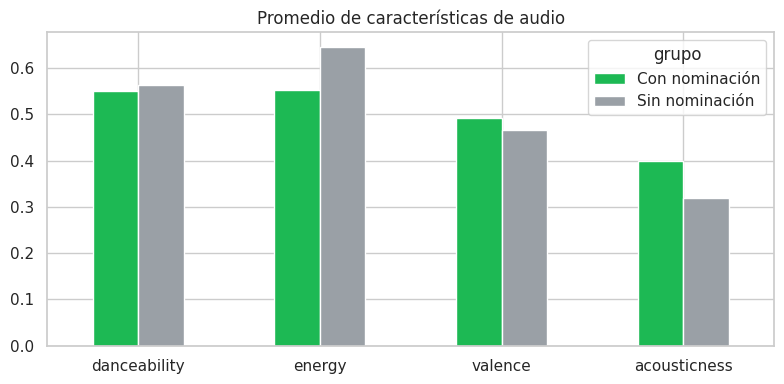

In [22]:
# Gráfico 4: características de audio, nominados vs no nominados
d = q("""SELECT CASE WHEN has_grammy_nomination = 1 THEN 'Con nominación' ELSE 'Sin nominación' END AS grupo,
                AVG(danceability) AS danceability, AVG(energy) AS energy,
                AVG(valence) AS valence, AVG(acousticness) AS acousticness
         FROM spotify_grammys_merged GROUP BY 1""")
d.set_index("grupo").T.plot.bar(figsize=(8, 4), color=["#1DB954", "#9aa0a6"])
plt.title("Promedio de características de audio"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

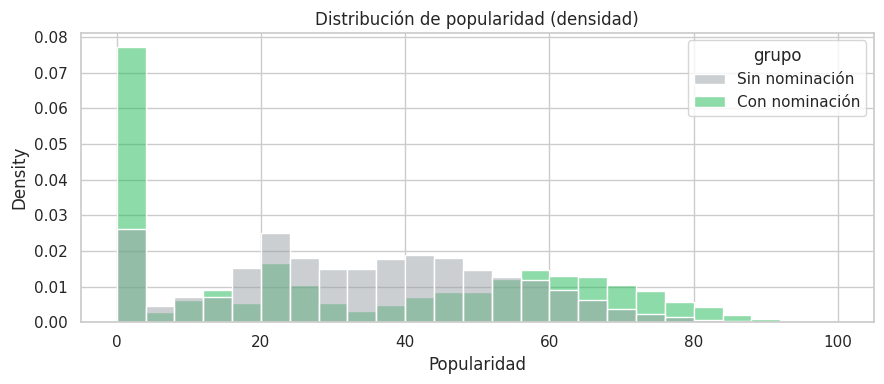

In [23]:
# Gráfico 5: distribución de popularidad por grupo
d = q("SELECT popularity, has_grammy_nomination AS nominado FROM spotify_grammys_merged")
d["grupo"] = d["nominado"].map({1: "Con nominación", 0: "Sin nominación"})
plt.figure(figsize=(9, 4))
sns.histplot(data=d, x="popularity", hue="grupo", bins=25, stat="density", common_norm=False,
             palette={"Con nominación": "#1DB954", "Sin nominación": "#9aa0a6"})
plt.title("Distribución de popularidad (densidad)"); plt.xlabel("Popularidad"); plt.tight_layout(); plt.show()
conn.close()

## 11. Conclusiones y decisiones de diseño
- **Base de datos:** SQLite (`data/etl_workshop.db`). Grammys se carga una vez a `grammys_raw` (fuente) y el resultado final queda en `spotify_grammys_merged`.
- **Validación:** las filas inválidas no se corrigen en silencio; se separan en `data/reports/rejected_rows.csv` y el estado queda en `validation_report.json`. Si superan el 5 % el DAG falla.
- **Merge:** Grammys se agrega por artista antes del cruce y se usa `LEFT JOIN`: cada canción aparece una sola vez y se puede comparar nominados contra no nominados.
- **Calidad de la fuente Grammys:** `winner` es `True` en todas las filas (no sirve para saber quién ganó) y `artist` viene vacío en ≈38 % de ellas; por eso se usan *nominaciones* y se recupera el artista desde `workers`.
- **Intercambio entre tareas:** archivos en `data/staging/` (no XCom) por el tamaño del dataset.
- **Limitaciones:** el cruce es por nombre normalizado exacto (puede haber homónimos o variantes que no coinciden) y los Grammys llegan hasta 2019, mientras que Spotify incluye música posterior.
- **Entregables generados:** `data/transformed_dataset.csv`, `data/reports/validation_report.json`, tabla `spotify_grammys_merged` y este reporte.

## 12. Exportar entregables
Descarga los archivos para subirlos al repositorio de GitHub (`data/` y evidencia de validación).

In [24]:
try:
    from google.colab import files
    for p in ["data/transformed_dataset.csv", "data/reports/validation_report.json"]:
        files.download(p)
except ImportError:
    print("Fuera de Colab: los archivos están en data/transformed_dataset.csv y data/reports/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>